<a href="https://colab.research.google.com/github/juanmorales2993/Ayudantias/blob/main/Ayudantia_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Ayudantía 6: Redes Neuronales (Perceptrón y MLP) + Workflow Completo**

**Ayudantes:**
- Maykol Medrano -- mmedrano2@uc.cl
- Pablo Acevedo -- pabloacevedo@uc.cl

Basado en el trabajo del equipo docente de semestres anteriores.

### **Contenidos**

1. **Perceptrón y MLP** — de la neurona artificial a redes multicapa.
2. **Workflow completo** — pipeline de ML aplicado a un problema de clasificación económica, integrando todo lo visto en el curso.

**Conceptos:**
- **Perceptrón** — clasificador lineal basado en una neurona artificial.
- **MLP (Multilayer Perceptron)** — red neuronal con capas ocultas que puede resolver problemas no lineales.
- **Backpropagation** — algoritmo de entrenamiento que ajusta los pesos propagando el error hacia atrás.
- **Early stopping** — detener el entrenamiento antes de que el modelo memorice el ruido.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn import datasets
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, roc_auc_score
)
from sklearn.pipeline import Pipeline

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

---

## **Parte 1: Del Perceptrón al Multilayer Perceptron (MLP)**

### **1.1 El perceptrón: la neurona artificial más simple**

El **perceptrón** es el modelo más elemental de red neuronal. Fue propuesto por Rosenblatt (1958) inspirándose en la neurona de McCulloch & Pitts (1943). Consiste en:

- $n$ **input neurons** (una por cada feature), con función de activación identidad.
- **1 output neuron**, que aplica una función de activación tipo escalón (step function).
- Un vector de **weights** $W$ y un **bias** $\theta$.

La salida del perceptrón es:

$$o = h\left(\sum_{j} W_j \cdot x_j + \theta\right)$$

donde $h(z) = 1$ si $z > 0$, y $0$ en caso contrario.

> **Conexión con econometría:** el perceptrón es esencialmente un clasificador lineal — traza un **hiperplano separador** en el espacio de features, de forma análoga a lo que hace una regresión logística. La diferencia clave es el **algoritmo de aprendizaje**: la logística maximiza la verosimilitud, el perceptrón actualiza pesos iterativamente cuando se equivoca.

#### **Algoritmo de aprendizaje del perceptrón**

1. Inicializar los weights $W$ aleatoriamente.
2. Para cada observación $(x_i, t_i)$, calcular $o_i = h(W \cdot x_i + \theta)$.
3. Si $o_i \neq t_i$: actualizar $\Delta W = \eta \cdot (t_i - o_i) \cdot x_i$.
4. Repetir hasta que $o_i = t_i$ para todas las observaciones.

$\eta$ es el **learning rate**: controla cuánto se ajustan los pesos en cada paso. Un $\eta$ muy alto puede hacer que el modelo oscile sin converger; uno muy bajo hace el entrenamiento lento pero estable.

#### **1.2 Limitación fundamental: el problema XOR**

El perceptrón solo puede resolver problemas **linealmente separables**. Un ejemplo clásico de lo que *no* puede resolver es el **XOR** (o exclusivo):

| $x_1$ | $x_2$ | $y$ (XOR) |
|---|---|---|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

No existe una línea recta que separe los 1s de los 0s. Esta limitación motivó el desarrollo de redes con **capas ocultas** (hidden layers) — el MLP.

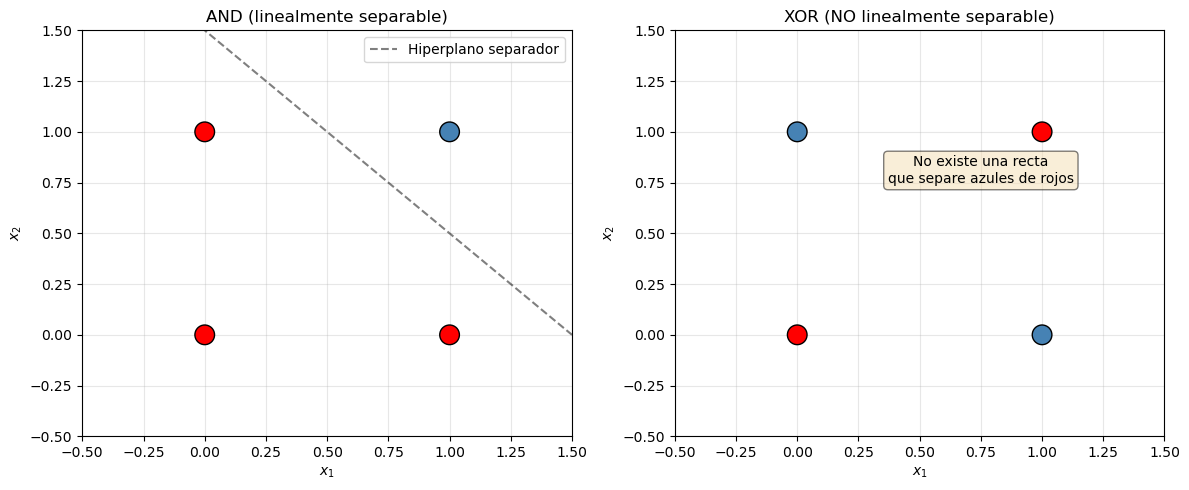

In [ ]:
# Ejemplo visual: XOR no es linealmente separable
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# AND (linealmente separable)
X_and = np.array([[0,0], [0,1], [1,0], [1,1]])
y_and = np.array([0, 0, 0, 1])
colors_and = ['red' if y == 0 else 'steelblue' for y in y_and]
axes[0].scatter(X_and[:, 0], X_and[:, 1], c=colors_and, s=200, edgecolors='black', zorder=3)
# Hiperplano separador para AND
x_line = np.linspace(-0.5, 1.5, 100)
axes[0].plot(x_line, 1.5 - x_line, 'k--', alpha=0.5, label='Hiperplano separador')
axes[0].set_title('AND (linealmente separable)', fontsize=12)
axes[0].set_xlabel('$x_1$')
axes[0].set_ylabel('$x_2$')
axes[0].set_xlim(-0.5, 1.5)
axes[0].set_ylim(-0.5, 1.5)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# XOR (NO linealmente separable)
X_xor = np.array([[0,0], [0,1], [1,0], [1,1]])
y_xor = np.array([0, 1, 1, 0])
colors_xor = ['red' if y == 0 else 'steelblue' for y in y_xor]
axes[1].scatter(X_xor[:, 0], X_xor[:, 1], c=colors_xor, s=200, edgecolors='black', zorder=3)
axes[1].set_title('XOR (NO linealmente separable)', fontsize=12)
axes[1].set_xlabel('$x_1$')
axes[1].set_ylabel('$x_2$')
axes[1].set_xlim(-0.5, 1.5)
axes[1].set_ylim(-0.5, 1.5)
axes[1].annotate('No existe una recta\nque separe azules de rojos',
                 xy=(0.75, 0.75), fontsize=10, ha='center',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### **1.3 Multilayer Perceptron (MLP)**

El MLP resuelve la limitación del perceptrón agregando una o más **hidden layers** (capas ocultas) entre el input y el output. Esta arquitectura permite aproximar virtualmente cualquier función no lineal (Teorema de Aproximación Universal, Cybenko 1989).

**Arquitectura de un MLP:**
- **Input layer:** recibe el vector de features $X$ (una neurona por variable).
- **Hidden layers:** una o más capas intermedias. Cada neurona aplica una función de activación no lineal.
- **Output layer:** entrega la predicción $\hat{y}$.

> **Feedforward:** la información fluye en una sola dirección (input $\to$ hidden $\to$ output). No hay ciclos.

#### **Funciones de activación**

La magia del MLP está en las funciones de activación **no lineales** de las hidden layers. Sin ellas, apilar capas lineales daría otra función lineal (y estaríamos de vuelta en el perceptrón).

| **Función** | **Fórmula** | **Rango** | **Uso típico** |
|---|---|---|---|
| Sigmoid (logística) | $\sigma(z) = \frac{1}{1 + e^{-z}}$ | $(0, 1)$ | Output en clasificación binaria |
| Tanh | $\tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}}$ | $(-1, 1)$ | Hidden layers (centrada en 0) |
| ReLU | $\max(0, z)$ | $[0, \infty)$ | Hidden layers (estándar moderno) |

> **Analogía con econometría:** la función sigmoid del output layer es exactamente la función logística que conocen de la regresión logística. La diferencia es que en el MLP, el input de esa sigmoide no es la combinación lineal de features originales, sino la transformación no lineal producida por las capas ocultas.

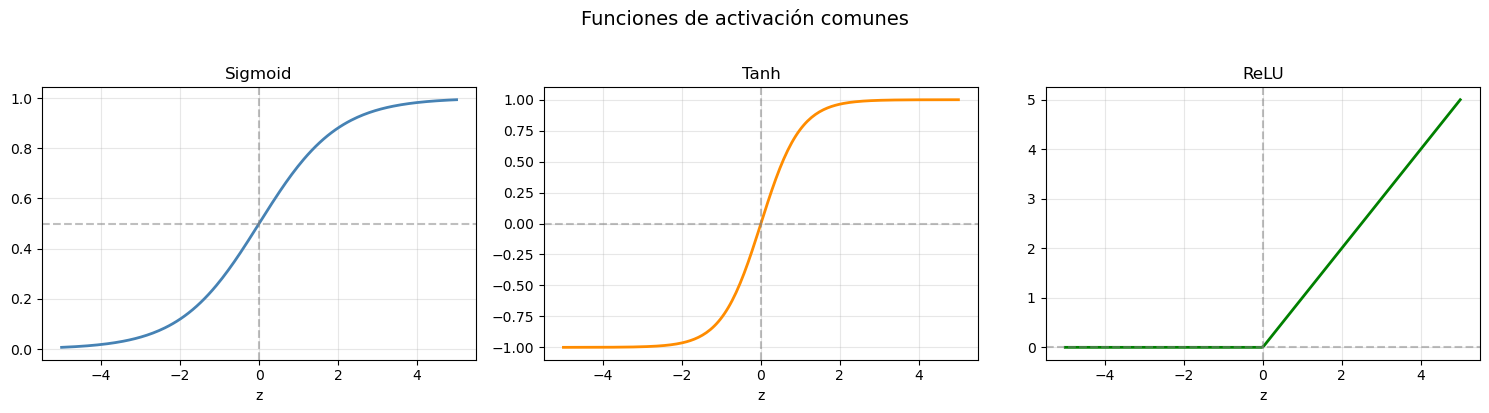

In [ ]:
# Visualización de las funciones de activación
z = np.linspace(-5, 5, 200)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Sigmoid
axes[0].plot(z, 1 / (1 + np.exp(-z)), color='steelblue', linewidth=2)
axes[0].set_title('Sigmoid', fontsize=12)
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
axes[0].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlabel('z')

# Tanh
axes[1].plot(z, np.tanh(z), color='darkorange', linewidth=2)
axes[1].set_title('Tanh', fontsize=12)
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlabel('z')

# ReLU
axes[2].plot(z, np.maximum(0, z), color='green', linewidth=2)
axes[2].set_title('ReLU', fontsize=12)
axes[2].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[2].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[2].grid(True, alpha=0.3)
axes[2].set_xlabel('z')

plt.suptitle('Funciones de activación comunes', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

#### **Backpropagation: cómo aprende un MLP**

El algoritmo de **backpropagation** entrena la red propagando el error desde la capa de salida hacia atrás:

1. **Forward pass:** se calcula la predicción $\hat{y}$ pasando los inputs a través de todas las capas.
2. **Calcular error:** se computa la función de pérdida $E_W$ (ej. cross-entropy para clasificación).
3. **Backward pass:** se calcula la gradiente $\nabla E_W = \left(\frac{\partial E_W}{\partial W_{11}}, \frac{\partial E_W}{\partial W_{12}}, \ldots\right)$ usando la regla de la cadena.
4. **Actualizar pesos:** $W_{\text{nuevo}} = W_{\text{anterior}} - \eta \cdot \nabla E_W$.

Cada pasada por todos los datos de entrenamiento se llama un **epoch**. El algoritmo normalmente necesita cientos o miles de epochs para converger.

> **Problemas prácticos:** el landscape de la función de error es no convexo — hay **mínimos locales**. Técnicas como **momentum**, **learning rate adaptativo** (Adam), y **mini-batches** (SGD estocástico) ayudan a escapar de ellos.

#### **Generalización en redes neuronales: Early Stopping**

Recordemos de la Ay. 4 que el objetivo no es minimizar el error de entrenamiento sino **generalizar**. En redes neuronales, la forma más práctica de evitar overfitting es el **early stopping**: detener el entrenamiento cuando el error de validación comienza a subir, incluso si el error de entrenamiento sigue bajando.

### **1.4 MLP en sklearn**

`sklearn` implementa `MLPClassifier` y `MLPRegressor`. Los hiperparámetros principales son:

| **Parámetro** | **Qué controla** | **Valores típicos** |
|---|---|---|
| `hidden_layer_sizes` | Neuronas por capa (ej: `(100,)` o `(64, 32)`) | Depende del problema |
| `activation` | Función de activación: `'relu'`, `'logistic'`, `'tanh'` | `'relu'` por defecto |
| `solver` | Optimizador: `'adam'`, `'sgd'`, `'lbfgs'` | `'adam'` por defecto |
| `learning_rate_init` | Learning rate inicial | 0.001 |
| `max_iter` | Máximo de epochs | 200-1000 |
| `early_stopping` | Detener si validación no mejora | `True` / `False` |
| `alpha` | Regularización L2 (penaliza pesos grandes) | 0.0001 |

> **Importante:** las redes neuronales son sensibles a la escala de los datos. **Siempre estandarizar** antes de entrenar (como hacíamos con Ridge/Lasso en la Ay. 4).

In [ ]:
# Generamos datos no lineales para mostrar la ventaja del MLP
from sklearn.datasets import make_moons

# make_moons genera dos semicírculos entrelazados: un problema no linealmente separable
X_moons, y_moons = make_moons(n_samples=500, noise=0.25, random_state=42)

X_tr, X_te, y_tr, y_te = train_test_split(X_moons, y_moons, test_size=0.3, random_state=42)

# Estandarizamos
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr)
X_te_sc = scaler.transform(X_te)

print(f'Datos: {X_moons.shape[0]} obs, {X_moons.shape[1]} features')
print(f'Train: {len(X_tr)} | Test: {len(X_te)}')
print(f'Distribución de clases (train): {np.bincount(y_tr)}')

Datos: 500 obs, 2 features
Train: 350 | Test: 150
Distribución de clases (train): [175 175]


In [ ]:
# Comparamos perceptrón, logística y MLP en el problema de moons
# El perceptrón es lineal -> no puede resolver este problema bien
perc = Perceptron(random_state=42)
perc.fit(X_tr_sc, y_tr)

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_tr_sc, y_tr)

# MLP con 1 hidden layer de 50 neuronas
mlp = MLPClassifier(hidden_layer_sizes=(50,), activation='relu',
                    solver='adam', max_iter=500, random_state=42)
mlp.fit(X_tr_sc, y_tr)

# Resultados
print(f'{"Modelo":25s} {"Acc Train":>10s} {"Acc Test":>10s}')
print('-' * 47)
for nombre, modelo in [('Perceptron', perc), ('Logistic Regression', log_reg), ('MLP (50,)', mlp)]:
    acc_tr = accuracy_score(y_tr, modelo.predict(X_tr_sc))
    acc_te = accuracy_score(y_te, modelo.predict(X_te_sc))
    print(f'{nombre:25s} {acc_tr:>10.4f} {acc_te:>10.4f}')

Modelo                     Acc Train   Acc Test
-----------------------------------------------
Perceptron                    0.8486     0.8533
Logistic Regression           0.8457     0.8600
MLP (50,)                     0.9171     0.9000


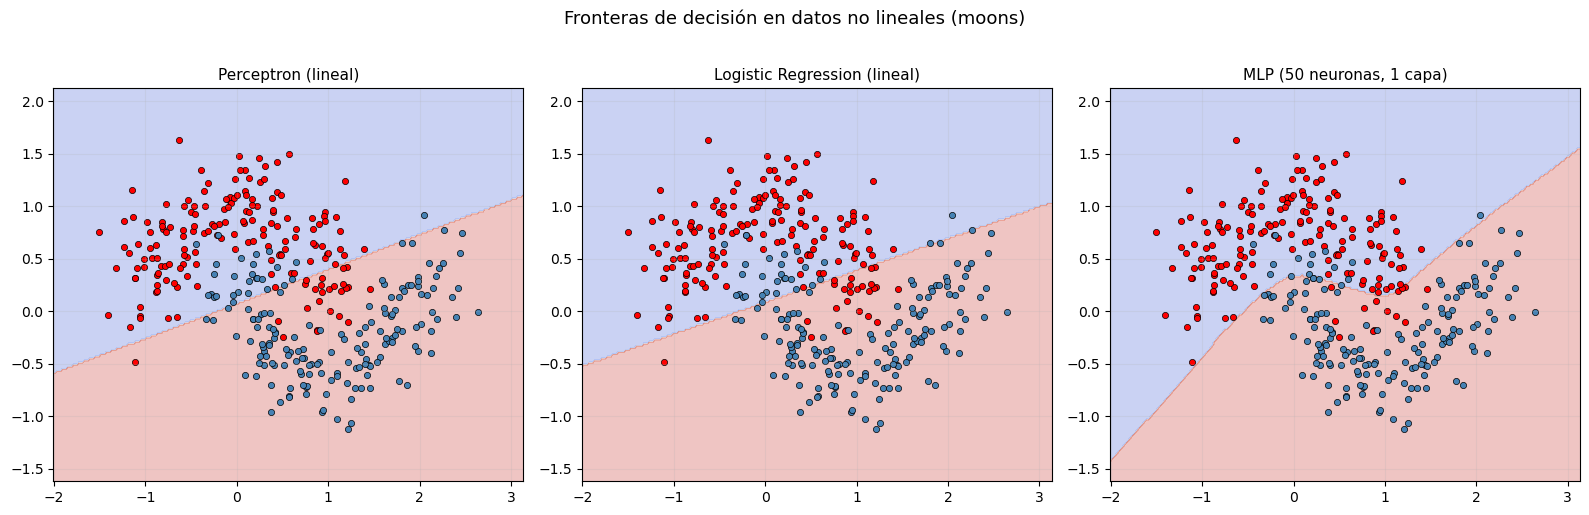

In [ ]:
# Visualizamos las fronteras de decisión de cada modelo
def plot_decision_boundary(ax, model, X, y, title, scaler):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_sc = scaler.transform(grid)
    Z = model.predict(grid_sc).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X[y==0, 0], X[y==0, 1], c='red', s=20, edgecolors='k', linewidth=0.5, label='Clase 0')
    ax.scatter(X[y==1, 0], X[y==1, 1], c='steelblue', s=20, edgecolors='k', linewidth=0.5, label='Clase 1')
    ax.set_title(title, fontsize=11)
    ax.grid(True, alpha=0.2)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

plot_decision_boundary(axes[0], perc, X_tr, y_tr, 'Perceptron (lineal)', scaler)
plot_decision_boundary(axes[1], log_reg, X_tr, y_tr, 'Logistic Regression (lineal)', scaler)
plot_decision_boundary(axes[2], mlp, X_tr, y_tr, 'MLP (50 neuronas, 1 capa)', scaler)

plt.suptitle('Fronteras de decisión en datos no lineales (moons)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

El perceptrón y la regresión logística trazan fronteras lineales — no capturan la estructura curva de los datos. El MLP con una capa oculta de 50 neuronas ReLU logra una frontera no lineal que se adapta mejor a la geometría del problema.

> **Analogía con árboles y RF:** los árboles de decisión también capturan no linealidades, pero lo hacen con cortes rectangulares (paralelos a los ejes). El MLP produce fronteras suaves — distintas formas de resolver el mismo problema.

#### **1.5 Efecto de la arquitectura: ¿cuántas capas y neuronas?**

Veamos cómo cambia el rendimiento al variar la arquitectura de la red.

In [ ]:
# Probamos distintas arquitecturas
arquitecturas = [
    ('1 capa, 10 neuronas', (10,)),
    ('1 capa, 50 neuronas', (50,)),
    ('1 capa, 100 neuronas', (100,)),
    ('2 capas, (50, 25)', (50, 25)),
    ('3 capas, (64, 32, 16)', (64, 32, 16)),
]

print(f'{"Arquitectura":30s} {"Acc Train":>10s} {"Acc Test":>10s} {"Params":>8s}')
print('-' * 62)

for nombre, layers in arquitecturas:
    mlp_i = MLPClassifier(hidden_layer_sizes=layers, activation='relu',
                          solver='adam', max_iter=500, random_state=42)
    mlp_i.fit(X_tr_sc, y_tr)

    # Contamos parámetros totales (weights + biases)
    n_params = sum(w.size for w in mlp_i.coefs_) + sum(b.size for b in mlp_i.intercepts_)
    acc_tr = accuracy_score(y_tr, mlp_i.predict(X_tr_sc))
    acc_te = accuracy_score(y_te, mlp_i.predict(X_te_sc))
    print(f'{nombre:30s} {acc_tr:>10.4f} {acc_te:>10.4f} {n_params:>8,}')

Arquitectura                    Acc Train   Acc Test   Params
--------------------------------------------------------------
1 capa, 10 neuronas                0.8543     0.8533       41
1 capa, 50 neuronas                0.9171     0.9000      201
1 capa, 100 neuronas               0.9429     0.9600      401
2 capas, (50, 25)                  0.9657     0.9533    1,451
3 capas, (64, 32, 16)              0.9629     0.9333    2,817


Con datos simples como `moons` (2 features, 500 obs), redes muy grandes no mejoran mucho y pueden empeorar el test accuracy — señal de overfitting. La clave es que **más parámetros no siempre es mejor**; la complejidad del modelo debe ser proporcional a la complejidad del problema.

> **Regla práctica:** comenzar con una capa oculta y pocas neuronas, luego ir aumentando si el modelo está en underfitting (error de entrenamiento alto). Si la brecha train-test se agranda, estamos en overfitting.

#### **1.6 Early stopping: la regularización natural de las redes neuronales**

In [ ]:
# Entrenamos dos MLPs: uno con early stopping y otro sin
mlp_no_es = MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu',
                          solver='adam', max_iter=500, random_state=42,
                          early_stopping=False)
mlp_no_es.fit(X_tr_sc, y_tr)

mlp_es = MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu',
                       solver='adam', max_iter=500, random_state=42,
                       early_stopping=True, validation_fraction=0.1,
                       n_iter_no_change=10)
mlp_es.fit(X_tr_sc, y_tr)

print('Sin Early Stopping:')
print(f'  Epochs usados: {mlp_no_es.n_iter_}')
print(f'  Acc Train: {accuracy_score(y_tr, mlp_no_es.predict(X_tr_sc)):.4f}')
print(f'  Acc Test:  {accuracy_score(y_te, mlp_no_es.predict(X_te_sc)):.4f}')
print()
print('Con Early Stopping:')
print(f'  Epochs usados: {mlp_es.n_iter_}')
print(f'  Acc Train: {accuracy_score(y_tr, mlp_es.predict(X_tr_sc)):.4f}')
print(f'  Acc Test:  {accuracy_score(y_te, mlp_es.predict(X_te_sc)):.4f}')

Sin Early Stopping:
  Epochs usados: 396
  Acc Train: 0.9657
  Acc Test:  0.9467

Con Early Stopping:
  Epochs usados: 27
  Acc Train: 0.8486
  Acc Test:  0.8667


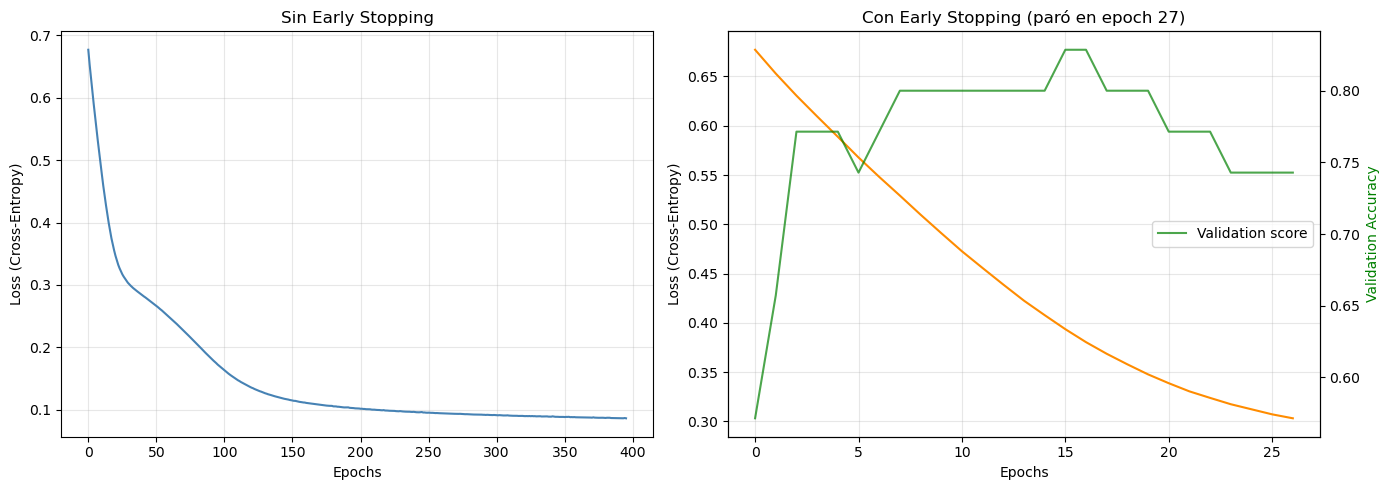

In [ ]:
# Curva de pérdida durante el entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(mlp_no_es.loss_curve_, color='steelblue', linewidth=1.5)
axes[0].set_title('Sin Early Stopping', fontsize=12)
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss (Cross-Entropy)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(mlp_es.loss_curve_, color='darkorange', linewidth=1.5)
if hasattr(mlp_es, 'validation_scores_') and mlp_es.validation_scores_ is not None:
    ax2 = axes[1].twinx()
    ax2.plot(mlp_es.validation_scores_, color='green', linewidth=1.5, alpha=0.7, label='Validation score')
    ax2.set_ylabel('Validation Accuracy', color='green')
    ax2.legend(loc='center right')
axes[1].set_title(f'Con Early Stopping (paró en epoch {mlp_es.n_iter_})', fontsize=12)
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss (Cross-Entropy)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Early stopping detiene el entrenamiento cuando el score de validación deja de mejorar durante `n_iter_no_change` epochs consecutivas. Es el equivalente neuronal del `early_stopping_rounds` de XGBoost que vimos en la Ay. 5.

---

## **Parte 2: Workflow Completo de ML — Predicción de Estrés Financiero Empresarial**

### **Resumen del problema**

**Contexto económico:** un equipo de estabilidad financiera del Banco Central necesita un sistema de alerta temprana (*early warning system*) para identificar empresas con alta probabilidad de entrar en **estrés financiero** (definido como incumplimiento de obligaciones de deuda o deterioro severo de su posición financiera).

**Pregunta económica:** ¿es posible predecir si una empresa entrará en estrés financiero en los próximos 12 meses, utilizando indicadores contables y financieros observables hoy?

**¿Por qué importa?** La identificación temprana de empresas en riesgo permite:
- Al regulador: focalizar la supervisión y anticipar riesgos sistémicos.
- A la banca: ajustar provisiones y políticas de crédito.
- Al banco central: monitorear la estabilidad del sistema financiero.

**Estrategia de solución:**
1. Construir un dataset con indicadores financieros de empresas (ratios contables, apalancamiento, rentabilidad, liquidez, tamaño).
2. Definir la variable objetivo: $y = 1$ si la empresa entra en estrés en los próximos 12 meses; $y = 0$ si no.
3. Aplicar el pipeline completo de ML: exploración, preprocesamiento, train/test split, entrenamiento de múltiples modelos (Logística, Árbol, Random Forest, XGBoost, MLP), evaluación con métricas de clasificación, y selección del mejor modelo.
4. Interpretar los resultados desde una perspectiva económica: ¿qué variables predicen mejor el estrés? ¿qué tipo de errores es más costoso (falsos positivos vs falsos negativos)?

> **Nota sobre los datos:** usaremos datos **sintéticos** calibrados para replicar patrones empíricos de la literatura de predicción de default corporativo (Altman, 1968; Ohlson, 1980). Las variables y distribuciones están inspiradas en datos reales pero no provienen de ninguna fuente confidencial.

---

### **2.1 Construcción del dataset**

Generamos datos de 2,000 empresas con 8 indicadores financieros. La variable objetivo (`estrés`) sigue un proceso generador de datos (DGP) que combina factores lineales, **interacciones entre variables** y **efectos umbral** — patrones no lineales que los modelos más simples (como la regresión logística) no pueden capturar completamente.

In [ ]:
# Simulamos datos de empresas con indicadores financieros
np.random.seed(42)
n = 2000

# Variables financieras (inspiradas en indicadores tipo Altman Z-score)
leverage = np.random.lognormal(mean=-0.5, sigma=0.7, size=n)  # Deuda/Activos
leverage = np.clip(leverage, 0.01, 3.0)

roe = np.random.normal(loc=0.08, scale=0.15, size=n)  # Retorno sobre patrimonio

current_ratio = np.random.lognormal(mean=0.5, sigma=0.5, size=n)  # Activo corriente / Pasivo corriente
current_ratio = np.clip(current_ratio, 0.1, 10.0)

interest_coverage = np.random.normal(loc=3.0, scale=2.5, size=n)  # EBIT / Gastos financieros

log_assets = np.random.normal(loc=10, scale=2, size=n)  # log(Activos totales) como proxy de tamaño

sales_growth = np.random.normal(loc=0.05, scale=0.20, size=n)  # Crecimiento de ventas YoY

cash_ratio = np.random.exponential(scale=0.3, size=n)  # Caja / Pasivos totales
cash_ratio = np.clip(cash_ratio, 0.0, 2.0)

age = np.random.poisson(lam=15, size=n) + 1  # Años desde la fundación

# DGP: probabilidad de estrés depende de los indicadores
# El DGP incluye efectos lineales, interacciones y umbrales (no linealidades)
z = (1.2 * leverage                         # Más deuda → más riesgo
     - 1.5 * roe                             # Menor rentabilidad → más riesgo
     - 0.6 * np.log(current_ratio + 1)       # Menor liquidez → más riesgo (relación log)
     - 0.3 * interest_coverage               # Menor cobertura de intereses → más riesgo
     - 0.2 * log_assets                      # Menor tamaño → más riesgo
     - 0.8 * sales_growth                    # Menor crecimiento → más riesgo
     - 1.2 * cash_ratio                      # Menos caja → más riesgo
     - 0.05 * np.log(age + 1)                # Menor antigüedad → más riesgo
     + 1.5 * leverage * (roe < 0)            # Interacción: deuda alta + pérdidas = peligro
     + 1.0 * (interest_coverage < 1.0)       # Umbral: cobertura de intereses insuficiente
     + 0.8 * leverage * (cash_ratio < 0.1)   # Interacción: alta deuda + sin liquidez
     - 0.5 * np.log(age + 1) * (leverage > 1)  # Empresa joven y apalancada
     + 1.0)                                  # Intercepto (calibrado para ~25% de estrés)

prob_estres = 1 / (1 + np.exp(-z))
estres = np.random.binomial(1, prob_estres)

# Construimos el DataFrame
df = pd.DataFrame({
    'leverage': leverage,
    'roe': roe,
    'current_ratio': current_ratio,
    'interest_coverage': interest_coverage,
    'log_assets': log_assets,
    'sales_growth': sales_growth,
    'cash_ratio': cash_ratio,
    'age': age,
    'estres': estres
})

print(f'Dataset: {df.shape[0]} empresas, {df.shape[1] - 1} features')
print(f'Tasa de estres: {df["estres"].mean():.1%} ({df["estres"].sum()} empresas)')
print()
df.head(8)

Dataset: 2000 empresas, 8 features
Tasa de estres: 23.6% (473 empresas)



,leverage,roe,current_ratio,interest_coverage,log_assets,sales_growth,cash_ratio,age,estres
0,0.858731,-0.021277,1.070636,0.214797,9.933949,-0.085699,0.141383,12,1
1,0.550579,0.058322,1.623198,1.422673,8.992699,-0.011100,0.258582,9,0
2,0.954452,-0.038863,1.663641,0.644850,9.655250,-0.069476,0.173228,14,1
3,1.761421,0.033806,2.088227,1.630010,11.429463,0.072084,0.005249,16,1
4,0.514836,-0.204042,0.832411,2.464624,12.555713,0.289436,1.534685,12,0
5,0.514842,0.111994,2.217285,5.092886,11.140975,-0.104208,0.235276,15,0
6,1.832075,0.080181,0.426477,2.197102,10.203446,0.250164,0.192526,17,0
7,1.037905,-0.042563,1.203288,-0.964064,12.996024,-0.106334,0.927788,19,0


La tasa de estrés es ~25%, lo que refleja un dataset moderadamente desbalanceado — consistente con la realidad (en escenarios de crisis puede llegar al 30-40%, en períodos normales al 5-10%).

> **Conexión con la Ay. 4:** recordemos que con clases desbalanceadas, el accuracy no es una buena métrica. Si solo predijéramos "no estrés" para todos, tendríamos ~80% de accuracy pero un modelo inútil para el regulador. Necesitaremos prestar atención al Recall (detectar las empresas en riesgo) y al AUC.

### **2.2 Análisis Exploratorio (EDA)**

In [ ]:
# Estadísticas descriptivas separadas por grupo
print('=== Empresas SIN estres ===')
print(df[df['estres'] == 0].describe().round(3).to_string())
print()
print('=== Empresas CON estres ===')
print(df[df['estres'] == 1].describe().round(3).to_string())

=== Empresas SIN estres ===
       leverage       roe  current_ratio  interest_coverage  log_assets  sales_growth  cash_ratio       age  estres
count  1527.000  1527.000       1527.000           1527.000    1527.000      1527.000    1527.000  1527.000  1527.0
mean      0.708     0.093          1.860              3.446      10.073         0.052       0.326    16.145     0.0
std       0.478     0.146          0.984              2.424       2.000         0.197       0.306     3.841     0.0
min       0.063    -0.373          0.337             -3.935       2.155        -0.625       0.000     5.000     0.0
25%       0.370    -0.001          1.189              1.830       8.757        -0.082       0.106    14.000     0.0
50%       0.584     0.094          1.659              3.305      10.095         0.051       0.238    16.000     0.0
75%       0.921     0.184          2.321              5.131      11.404         0.184       0.458    19.000     0.0
max       3.000     0.669          7.761    

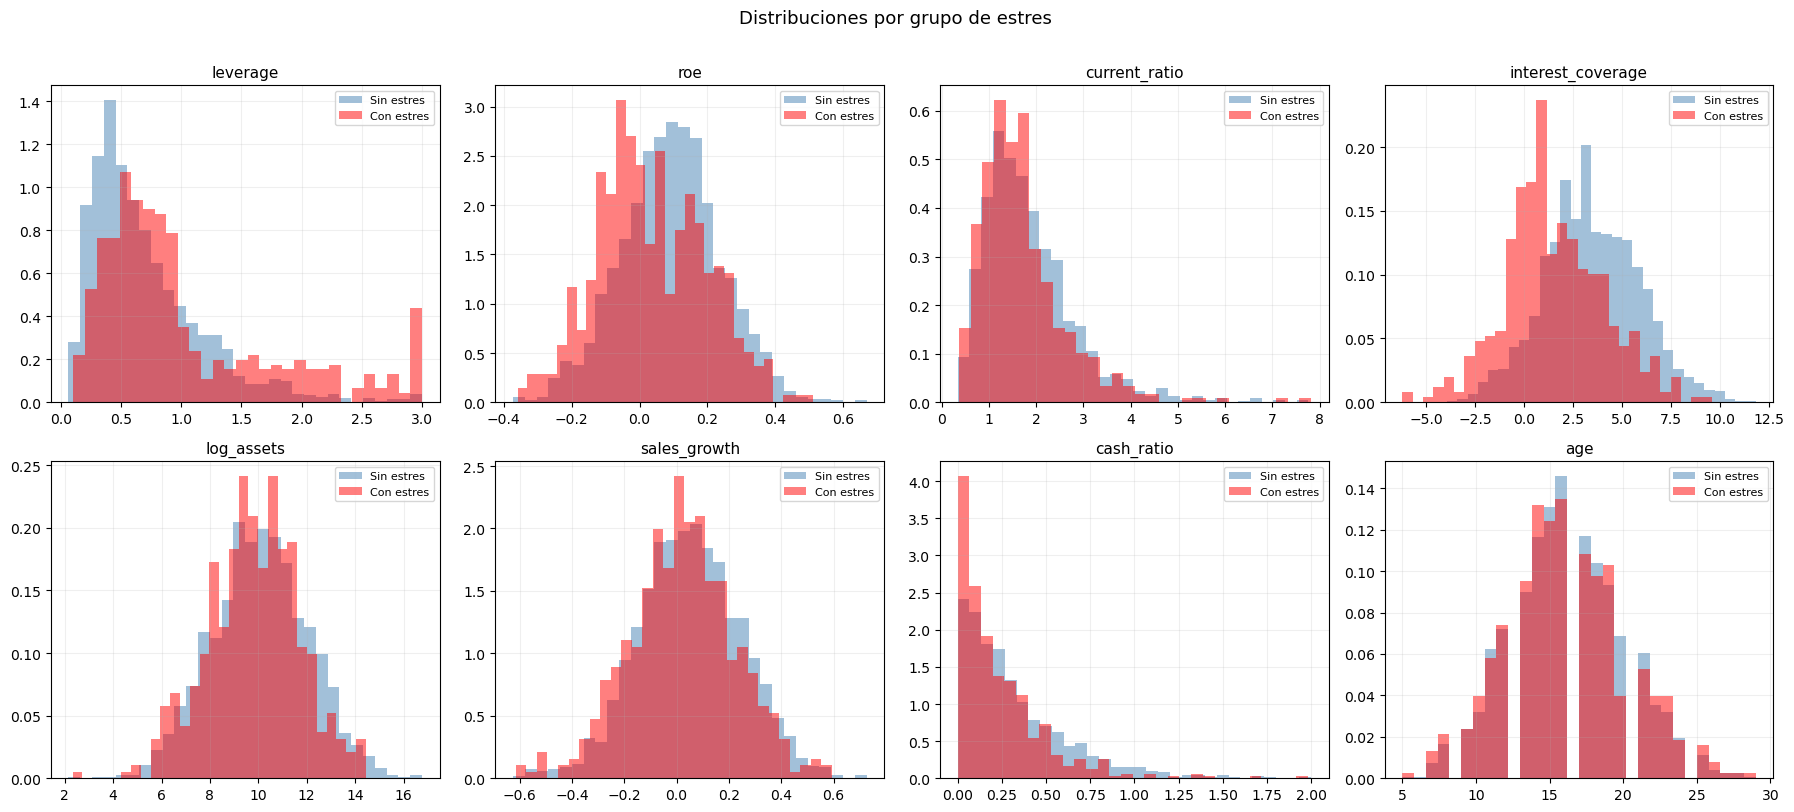

In [ ]:
# Distribuciones de las variables clave por grupo
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
features_plot = ['leverage', 'roe', 'current_ratio', 'interest_coverage',
                 'log_assets', 'sales_growth', 'cash_ratio', 'age']

for ax, feat in zip(axes.ravel(), features_plot):
    for label, color in [(0, 'steelblue'), (1, 'red')]:
        subset = df[df['estres'] == label][feat]
        ax.hist(subset, bins=30, alpha=0.5, color=color, density=True,
                label='Sin estres' if label == 0 else 'Con estres')
    ax.set_title(feat, fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

plt.suptitle('Distribuciones por grupo de estres', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

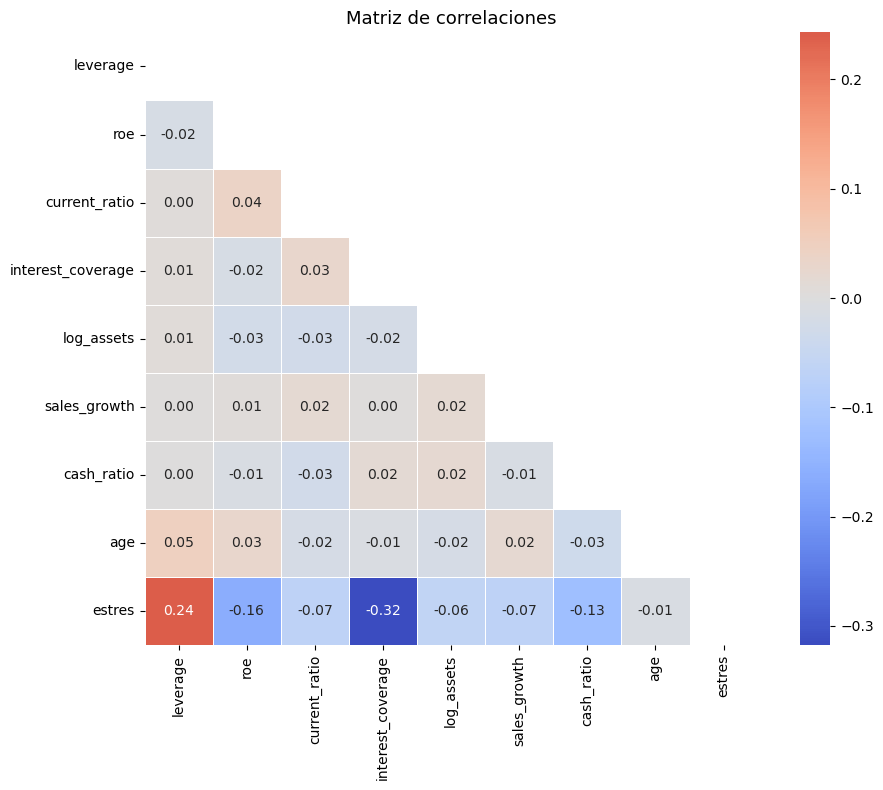

In [ ]:
# Matriz de correlaciones
fig, ax = plt.subplots(figsize=(10, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title('Matriz de correlaciones', fontsize=13)
plt.tight_layout()
plt.show()

**Observaciones del EDA:**
- Las empresas en estrés tienden a tener mayor apalancamiento, menor rentabilidad (ROE), menor cobertura de intereses y menor ratio de caja — consistente con la teoría financiera.
- `leverage` y `cash_ratio` muestran las diferencias más marcadas entre los dos grupos.
- No hay colinealidad extrema entre las features, lo cual es bueno para la interpretación de los modelos.

### **2.3 Preprocesamiento y Split**

In [ ]:
# Definimos features y target
features = ['leverage', 'roe', 'current_ratio', 'interest_coverage',
            'log_assets', 'sales_growth', 'cash_ratio', 'age']
X = df[features]
y = df['estres']

# Train/test split estratificado para mantener la proporción de clases
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f'Train: {len(X_train)} obs | Test: {len(X_test)} obs')
print(f'Tasa estres train: {y_train.mean():.1%} | test: {y_test.mean():.1%}')

# Estandarizamos (necesario para logística y MLP, no afecta a árboles)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

Train: 1500 obs | Test: 500 obs
Tasa estres train: 23.7% | test: 23.6%


Usamos `stratify=y` para asegurar que la proporción de estrés sea la misma en train y test. Esto es importante cuando las clases están desbalanceadas — sin estratificación, podríamos obtener un test set con proporción muy distinta por azar.

### **2.4 Entrenamiento de modelos**

Entrenamos 5 modelos, incorporando todo lo visto en el curso:

| **Modelo** | **Ayudantía** | **Tipo** |
|---|---|---|
| Regresión Logística | Ay. 3 y 4 | Baseline lineal |
| Árbol de Decisión | Ay. 3 | No lineal, interpretable |
| Random Forest | Ay. 5 | Ensemble (Bagging) |
| XGBoost | Ay. 5 | Ensemble (Boosting) |
| MLP | Ay. 6 (hoy) | Red neuronal |

In [ ]:
# 1. Regresión Logística (baseline)
# Es el modelo más simple y el que debería funcionar si la relación es aproximadamente lineal
t0 = time.time()
log_model = LogisticRegression(random_state=42, max_iter=1000)
log_model.fit(X_train_sc, y_train)
t_log = time.time() - t0
print(f'Logistic Regression entrenada en {t_log:.2f}s')

Logistic Regression entrenada en 0.00s


In [ ]:
# 2. Árbol de Decisión (regularizado con max_depth)
# Los árboles no necesitan estandarización, pero usamos X_train_sc por consistencia
t0 = time.time()
tree_model = DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, random_state=42)
tree_model.fit(X_train, y_train)
t_tree = time.time() - t0
print(f'Decision Tree entrenado en {t_tree:.2f}s')

Decision Tree entrenado en 0.00s


In [ ]:
# 3. Random Forest
t0 = time.time()
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=10, min_samples_leaf=10,
    random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)
t_rf = time.time() - t0
print(f'Random Forest entrenado en {t_rf:.2f}s')

Random Forest entrenado en 0.13s


In [ ]:
# 4. XGBoost
t0 = time.time()
xgb_model = XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    random_state=42, n_jobs=-1, eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)
t_xgb = time.time() - t0
print(f'XGBoost entrenado en {t_xgb:.2f}s')

XGBoost entrenado en 0.23s


In [ ]:
# 5. MLP
# Usamos datos estandarizados (crucial para redes neuronales)
t0 = time.time()
mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),  # 2 capas: 64 y 32 neuronas
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42,
    early_stopping=True,          # Detener si validación no mejora
    validation_fraction=0.1,      # 10% del train para validación interna
    n_iter_no_change=15           # Paciencia: 15 epochs sin mejora
)
mlp_model.fit(X_train_sc, y_train)
t_mlp = time.time() - t0
print(f'MLP entrenado en {t_mlp:.2f}s (epochs: {mlp_model.n_iter_})')

MLP entrenado en 0.05s (epochs: 26)


### **2.5 Evaluación comparativa**

In [ ]:
# Tabla comparativa de todos los modelos
modelos = [
    ('Logistic Regression', log_model, X_train_sc, X_test_sc, t_log),
    ('Decision Tree', tree_model, X_train.values, X_test.values, t_tree),
    ('Random Forest', rf_model, X_train.values, X_test.values, t_rf),
    ('XGBoost', xgb_model, X_train.values, X_test.values, t_xgb),
    ('MLP (64, 32)', mlp_model, X_train_sc, X_test_sc, t_mlp),
]

print(f'{"Modelo":25s} {"Acc Test":>9s} {"Prec":>6s} {"Recall":>7s} {"F1":>6s} {"AUC":>6s} {"Tiempo":>8s}')
print('-' * 70)

resultados = []
for nombre, modelo, Xtr, Xte, t_elapsed in modelos:
    y_pred = modelo.predict(Xte)
    y_prob = modelo.predict_proba(Xte)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    print(f'{nombre:25s} {acc:>9.4f} {prec:>6.3f} {rec:>7.3f} {f1:>6.3f} {auc:>6.3f} {t_elapsed:>7.2f}s')

    resultados.append({
        'modelo': nombre, 'accuracy': acc, 'precision': prec,
        'recall': rec, 'f1': f1, 'auc': auc
    })

df_res = pd.DataFrame(resultados)

Modelo                     Acc Test   Prec  Recall     F1    AUC   Tiempo
----------------------------------------------------------------------
Logistic Regression          0.8160  0.681   0.415  0.516  0.818    0.00s
Decision Tree                0.7920  0.580   0.432  0.495  0.791    0.00s
Random Forest                0.8160  0.703   0.381  0.495  0.821    0.13s
XGBoost                      0.7940  0.582   0.449  0.507  0.796    0.23s
MLP (64, 32)                 0.8140  0.736   0.331  0.456  0.802    0.05s


**Lectura de los resultados:**

- **Accuracy** no varía mucho entre modelos porque la clase mayoritaria domina. No es la métrica relevante aquí.
- **Recall** mide la proporción de empresas en estrés que el modelo detecta — es la métrica que más le importa al regulador (no dejar pasar empresas en riesgo).
- **AUC** permite una comparación global independiente del umbral de clasificación.
- **Precision** mide cuántas de las alertas del modelo son reales — importa para no desperdiciar recursos de supervisión.

> **Decisión económica:** el trade-off Precision-Recall refleja un dilema real. Si el banco central prefiere **no dejar pasar ninguna empresa en riesgo** (aun a costa de investigar algunas sanas), debería priorizar Recall. Si los recursos de supervisión son muy escasos, debería cuidar la Precision.

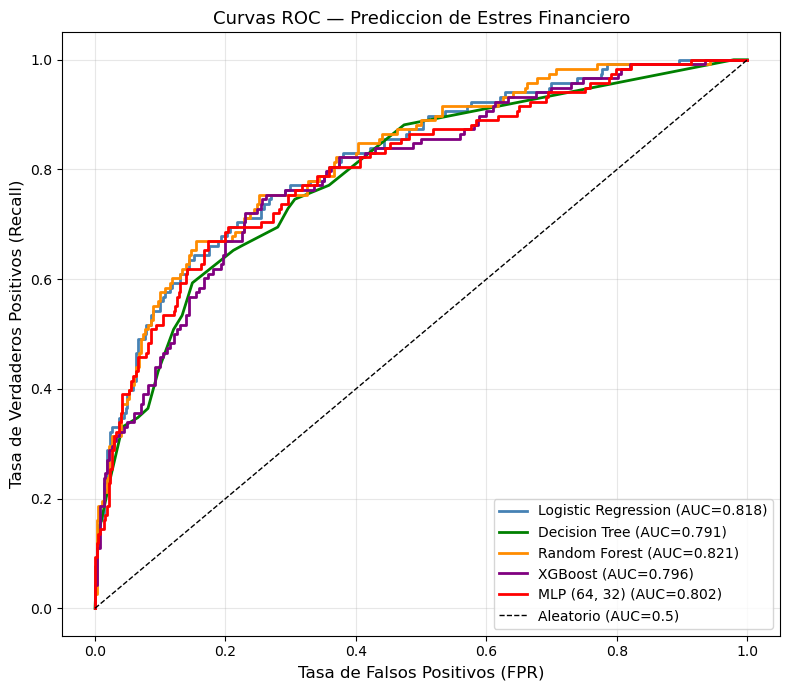

In [ ]:
# Curvas ROC comparadas
fig, ax = plt.subplots(figsize=(8, 7))
colores = ['steelblue', 'green', 'darkorange', 'purple', 'red']

for (nombre, modelo, _, Xte, _), color in zip(modelos, colores):
    y_prob = modelo.predict_proba(Xte)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{nombre} (AUC={auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatorio (AUC=0.5)')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (Recall)', fontsize=12)
ax.set_title('Curvas ROC — Prediccion de Estres Financiero', fontsize=13)
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

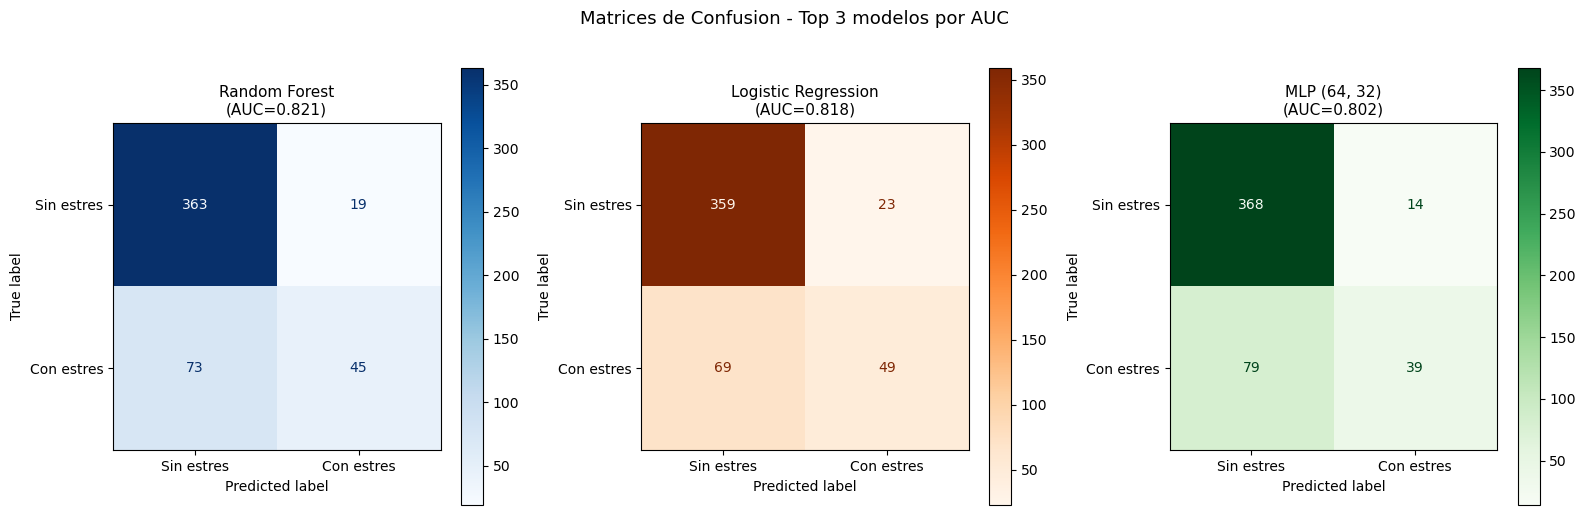

In [ ]:
# Matrices de confusión lado a lado para los 3 mejores modelos
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Identificamos los 3 con mejor AUC
top3 = df_res.nlargest(3, 'auc')
cmaps = ['Blues', 'Oranges', 'Greens']

for ax, (_, row), cmap in zip(axes, top3.iterrows(), cmaps):
    nombre = row['modelo']
    # Buscamos el modelo correspondiente
    for n, m, _, Xte, _ in modelos:
        if n == nombre:
            y_pred = m.predict(Xte)
            cm = confusion_matrix(y_test, y_pred)
            ConfusionMatrixDisplay(cm, display_labels=['Sin estres', 'Con estres']).plot(
                ax=ax, cmap=cmap, values_format='d')
            ax.set_title(f'{nombre}\n(AUC={row["auc"]:.3f})', fontsize=11)
            break

plt.suptitle('Matrices de Confusion - Top 3 modelos por AUC', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### **2.6 Feature Importance**

¿Qué variables financieras son más relevantes para predecir el estrés? Comparamos la importancia según RF y XGBoost.

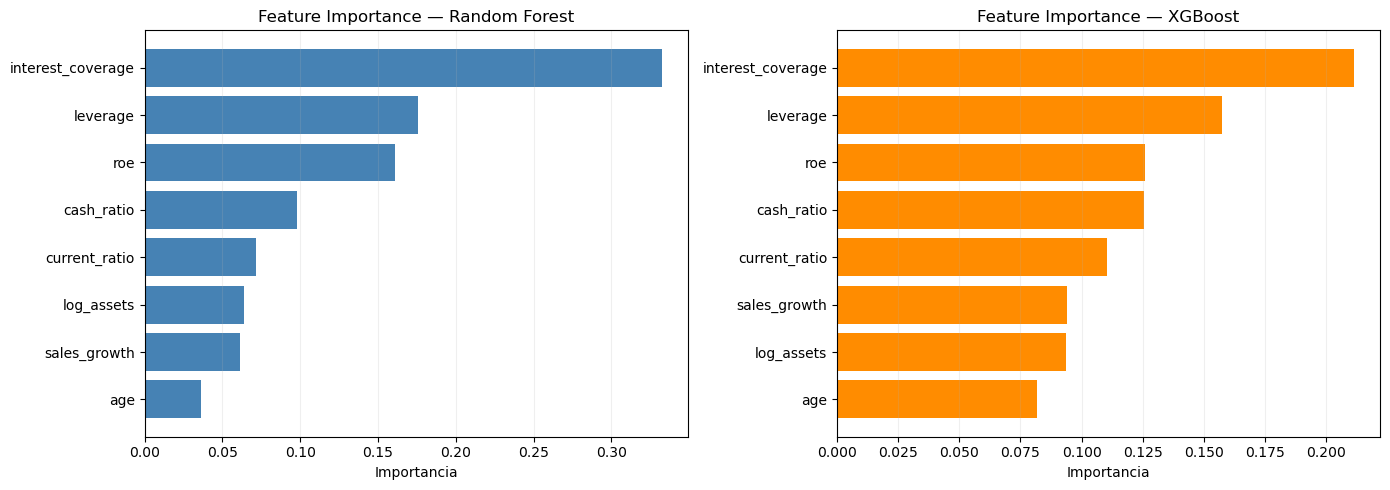

In [ ]:
# Feature importance de RF y XGBoost
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, modelo, nombre, color in [
    (axes[0], rf_model, 'Random Forest', 'steelblue'),
    (axes[1], xgb_model, 'XGBoost', 'darkorange')
]:
    imp = pd.DataFrame({
        'feature': features,
        'importance': modelo.feature_importances_
    }).sort_values('importance', ascending=True)

    ax.barh(imp['feature'], imp['importance'], color=color)
    ax.set_xlabel('Importancia')
    ax.set_title(f'Feature Importance — {nombre}', fontsize=12)
    ax.grid(True, alpha=0.2, axis='x')

plt.tight_layout()
plt.show()

**Interpretación económica de la importancia:**

- **Leverage** y **cash_ratio** aparecen como las variables más predictivas — consistente con la idea de que la estructura de capital y la posición de liquidez son los mejores indicadores de riesgo de estrés.
- **ROE** y **interest_coverage** también pesan: empresas poco rentables y con dificultades para cubrir sus gastos financieros son más propensas al estrés.
- **Age** y **sales_growth** tienen menor importancia relativa, aunque contribuyen al modelo.

> **Conexión con la literatura:** estos resultados son consistentes con el Z-score de Altman (1968), que usa ratios de liquidez, rentabilidad, apalancamiento y tamaño para predecir quiebras. Los modelos de ML capturan patrones similares pero permitiendo interacciones no lineales entre las variables.

### **2.7 Sensibilidad al umbral de clasificación**

Recordemos de la Ay. 4 que podemos ajustar el umbral de clasificación según la prioridad del problema.

In [ ]:
# Análisis de umbral para el mejor modelo
mejor_nombre = df_res.loc[df_res['auc'].idxmax(), 'modelo']
print(f'Modelo con mejor AUC: {mejor_nombre}')

# Obtenemos las probabilidades del mejor modelo
for n, m, _, Xte, _ in modelos:
    if n == mejor_nombre:
        y_prob_mejor = m.predict_proba(Xte)[:, 1]
        break

umbrales = [0.2, 0.3, 0.4, 0.5, 0.6]

print(f'\n{"Umbral":>8s} {"Precision":>10s} {"Recall":>8s} {"F1":>6s}')
print('-' * 36)

for u in umbrales:
    y_pred_u = (y_prob_mejor >= u).astype(int)
    prec = precision_score(y_test, y_pred_u, zero_division=0)
    rec = recall_score(y_test, y_pred_u)
    f1 = f1_score(y_test, y_pred_u, zero_division=0)
    print(f'{u:>8.1f} {prec:>10.3f} {rec:>8.3f} {f1:>6.3f}')

print()
print('Umbral bajo (0.2): detecta mas empresas en riesgo (alto Recall) pero genera mas falsas alarmas.')
print('Umbral alto (0.6): pocas falsas alarmas (alta Precision) pero puede dejar pasar empresas en riesgo.')
print('La eleccion depende del costo relativo de cada tipo de error para el regulador.')

Modelo con mejor AUC: Random Forest

  Umbral  Precision   Recall     F1
------------------------------------
     0.2      0.379    0.847  0.524
     0.3      0.491    0.712  0.581
     0.4      0.622    0.585  0.603
     0.5      0.703    0.381  0.495
     0.6      0.880    0.186  0.308

Umbral bajo (0.2): detecta mas empresas en riesgo (alto Recall) pero genera mas falsas alarmas.
Umbral alto (0.6): pocas falsas alarmas (alta Precision) pero puede dejar pasar empresas en riesgo.
La eleccion depende del costo relativo de cada tipo de error para el regulador.


---

### **Resumen y Takeaways**

**Parte 1 — Perceptrón y MLP:**
- El perceptrón es un clasificador lineal: solo puede resolver problemas linealmente separables.
- El MLP agrega capas ocultas con funciones de activación no lineales, permitiendo capturar relaciones complejas.
- Backpropagation ajusta los pesos propagando el error desde la salida hacia atrás.
- Early stopping es la forma estándar de regularizar redes neuronales (detiene el entrenamiento antes de memorizar el ruido).
- Las redes neuronales **requieren estandarización** de los datos.

**Parte 2 — Workflow completo:**
- Un pipeline de ML incluye: exploración (EDA), preprocesamiento (escalar, split estratificado), entrenamiento de múltiples modelos, evaluación con métricas apropiadas al problema, e interpretación.
- En problemas de clasificación desbalanceada (como estrés financiero), accuracy es insuficiente — hay que mirar Recall, Precision, F1 y AUC.
- La elección de umbral de clasificación es una **decisión económica**, no estadística: depende del costo relativo de falsos positivos vs. falsos negativos.
- Random Forest y XGBoost suelen dominar en datos tabulares. MLP es competitivo pero requiere más tuning.
- Feature importance confirma lo que la teoría financiera predice: leverage, liquidez y rentabilidad son los mejores predictores de estrés.

**Tabla resumen de modelos vistos en el curso:**

| **Modelo** | **Tipo** | **Ventaja principal** | **Limitación** |
|---|---|---|---|
| Regresión Lineal / Logística | Lineal | Interpretable, rápido, baseline | No captura no linealidades |
| Árbol de Decisión | No lineal | Interpretable, visual | Inestable, tiende a overfitting |
| Random Forest | Ensemble (Bagging) | Robusto, poco tuning | Lento con muchos árboles |
| XGBoost | Ensemble (Boosting) | Mejor accuracy en tabulares | Más sensible a hiperparámetros |
| MLP | Red neuronal | Aproximador universal, flexible | Requiere estandarización, más tuning, caja negra |

---

##### *Para profundizar*

*Libros:*
- *Neural Networks: A Comprehensive Foundation* (Haykin, 1999) — referencia completa sobre redes neuronales.
- *Pattern Recognition and Machine Learning* (Bishop, 2006) — Cap. 5 (Neural Networks).
- *Deep Learning* (Goodfellow, Bengio, Courville, 2016) — gratuito en [deeplearningbook.org](https://www.deeplearningbook.org).

*Documentación oficial:*
- scikit-learn — [Neural network models](https://scikit-learn.org/stable/modules/neural_network_supervised.html)

*Videos:*
- 3Blue1Brown: *Neural Networks* (serie visual de 4 videos, altamente recomendada).
- StatQuest (Josh Starmer): *Neural Networks / Deep Learning*.

*Artículos clásicos de credit scoring:*
- Altman (1968): *Financial Ratios, Discriminant Analysis and the Prediction of Corporate Bankruptcy*.
- Ohlson (1980): *Financial Ratios and the Probabilistic Prediction of Bankruptcy*.